# 개인정보보호법 Multi-Agent Architecture

**기반**: `05_privacy_law_graph.ipynb` (Single Self-RAG)  
**발전**: Supervisor + Specialist Agents 패턴

## 아키텍처 개요

```
START
  ↓
supervisor  ← 질문을 분석하여 전문 에이전트 선택
  ├── collection_agent  (수집·이용·제3자 제공: 제15~18조)
  ├── sensitive_agent   (민감정보·고유식별정보: 제23~24조)
  ├── security_agent    (안전관리·유출신고: 제29~31조·34조)
  ├── rights_agent      (정보주체 권리: 제35~39조)
  └── general_agent     (총칙·원칙: 제1~5조)
        ↓
  quality_checker  ← 환각(hallucination) 검증
        ├── hallucinated   → 동일 에이전트 재실행
        └── not hallucinated → END
```

## Single Agent vs Multi-Agent 비교

| 항목 | Single Agent (05) | Multi-Agent (06) |
|------|------------------|------------------|
| 라우팅 | 없음 (항상 동일 흐름) | Supervisor가 전문가 선택 |
| 검색 | 일반 retriever | 에이전트별 전문 프롬프트 |
| 답변 품질 | 범용 RAG prompt | 도메인 특화 system prompt |
| 확장성 | 에이전트 추가 어려움 | 에이전트 추가/교체 용이 |

## Step 1. 환경 설정

In [1]:
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

# 공유 LLM & 임베딩
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
embedding = OpenAIEmbeddings(model='text-embedding-3-large')

# 05에서 생성한 privacy-index 재사용
vectorstore = PineconeVectorStore(
    index_name='privacy-index',
    embedding=embedding
)
retriever = vectorstore.as_retriever(search_kwargs={'k': 3})

print('환경 설정 완료')

c:\workspace\langgraph_work\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


환경 설정 완료


## Step 2. Multi-Agent State 정의

Single Agent와의 차이점:
- `selected_agent`: supervisor가 선택한 에이전트 이름
- `retry_count`: 환각 발생 시 무한 루프 방지

In [2]:
from typing_extensions import TypedDict, List, Literal
from langchain_core.documents import Document

class MultiAgentState(TypedDict):
    query: str                  # 사용자 질문
    selected_agent: str         # supervisor가 선택한 에이전트
    context: List[Document]     # 검색된 문서
    answer: str                 # 에이전트가 생성한 답변
    retry_count: int            # 환각 재시도 횟수 (최대 2회)

## Step 3. Supervisor 에이전트

질문을 분석하여 5개 전문 에이전트 중 하나로 라우팅합니다.  
Structured Output으로 라우팅 결정을 강제합니다.

In [3]:
from pydantic import BaseModel, Field

class RouteDecision(BaseModel):
    """Supervisor의 라우팅 결정"""
    agent: Literal['collection', 'sensitive', 'security', 'rights', 'general'] = Field(
        description="선택할 전문 에이전트"
    )
    reason: str = Field(description="에이전트 선택 이유")

supervisor_prompt_template = """
당신은 개인정보보호법 전문 시스템의 Supervisor입니다.
사용자의 질문을 분석하여 가장 적합한 전문 에이전트를 선택하세요.

에이전트 안내:
- collection  : 개인정보 수집·이용·제3자 제공·목적 외 이용 (제15~18조)
- sensitive   : 민감정보(건강·신념 등) 및 고유식별정보(주민번호 등) (제23~24조)
- security    : 안전조치 의무, 처리방침 수립, 보호책임자, 유출 신고 (제29~31조, 제34조)
- rights      : 정보주체 열람·정정·삭제·처리정지·손해배상 (제35~39조)
- general     : 법의 목적, 정의, 원칙, 정보주체 권리 개요, 국가 책무 (제1~5조)

사용자 질문: {query}
"""

from langchain_core.prompts import ChatPromptTemplate

supervisor_prompt = ChatPromptTemplate.from_template(supervisor_prompt_template)
structured_llm = llm.with_structured_output(RouteDecision)
supervisor_chain = supervisor_prompt | structured_llm

def supervisor(state: MultiAgentState) -> MultiAgentState:
    """질문을 분석하여 전문 에이전트를 선택합니다."""
    query = state['query']
    decision = supervisor_chain.invoke({'query': query})
    print(f'[supervisor] → {decision.agent} | 이유: {decision.reason}')
    return {'selected_agent': decision.agent, 'retry_count': 0}

## Step 4. Supervisor 라우팅 엣지

`selected_agent` 값에 따라 해당 전문 에이전트 노드로 분기합니다.

In [4]:
def route_to_agent(state: MultiAgentState) -> str:
    """supervisor가 선택한 에이전트로 라우팅합니다."""
    return state['selected_agent']

## Step 5. 전문 에이전트 정의

각 에이전트는 동일한 retriever를 사용하지만, 도메인 특화 system prompt를 가집니다.  
공통 함수 `run_specialist_agent()`로 코드 중복을 최소화합니다.

In [5]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 전문 에이전트 공통 RAG 프롬프트 (도메인별 system_context 삽입)
specialist_rag_template = """
당신은 개인정보보호법 전문 AI입니다.
전문 영역: {domain_context}

아래 법령 문서를 참고하여 사용자의 질문에 정확하고 구체적으로 답변하세요.
법령에 근거한 내용만 답변하고, 불확실한 내용은 '법령에서 확인되지 않는 내용입니다'라고 명시하세요.

법령 문서:
{context}

질문: {question}

답변:
"""

specialist_prompt = PromptTemplate.from_template(specialist_rag_template)

# 에이전트별 도메인 설명
DOMAIN_CONTEXTS = {
    'collection': '개인정보 수집·이용(제15조), 수집 제한(제16조), 제3자 제공(제17조), 목적 외 이용·제공 제한(제18조)',
    'sensitive': '민감정보 처리 제한(제23조), 고유식별정보 처리 제한(제24조), 업무위탁(제26조)',
    'security': '안전조치 의무(제29조), 개인정보 처리방침(제30조), 보호책임자 지정(제31조), 유출 통지·신고(제34조)',
    'rights': '개인정보 열람(제35조), 정정·삭제(제36조), 처리정지(제37조), 손해배상(제39조)',
    'general': '법의 목적(제1조), 정의(제2조), 보호 원칙(제3조), 정보주체 권리(제4조), 국가 책무(제5조)',
}

def run_specialist_agent(state: MultiAgentState, agent_name: str) -> MultiAgentState:
    """전문 에이전트 공통 실행 함수: retrieve → generate"""
    query = state['query']
    domain_context = DOMAIN_CONTEXTS[agent_name]
    
    print(f'[{agent_name}_agent] 검색 중...')
    docs = retriever.invoke(query)
    
    rag_chain = specialist_prompt | llm | StrOutputParser()
    answer = rag_chain.invoke({
        'domain_context': domain_context,
        'context': docs,
        'question': query
    })
    
    print(f'[{agent_name}_agent] 답변 생성 완료')
    return {'context': docs, 'answer': answer}

In [6]:
# 5개 전문 에이전트 노드 정의

def collection_agent(state: MultiAgentState) -> MultiAgentState:
    """수집·이용·제3자 제공 전문 에이전트 (제15~18조)"""
    return run_specialist_agent(state, 'collection')

def sensitive_agent(state: MultiAgentState) -> MultiAgentState:
    """민감정보·고유식별정보 전문 에이전트 (제23~24조)"""
    return run_specialist_agent(state, 'sensitive')

def security_agent(state: MultiAgentState) -> MultiAgentState:
    """안전관리·유출신고 전문 에이전트 (제29~31조·34조)"""
    return run_specialist_agent(state, 'security')

def rights_agent(state: MultiAgentState) -> MultiAgentState:
    """정보주체 권리 전문 에이전트 (제35~39조)"""
    return run_specialist_agent(state, 'rights')

def general_agent(state: MultiAgentState) -> MultiAgentState:
    """총칙·원칙 전문 에이전트 (제1~5조)"""
    return run_specialist_agent(state, 'general')

## Step 6. Quality Checker (품질 검증 에이전트)

생성된 답변이 법령 문서에 근거하는지 검증합니다.  
환각 감지 시 동일 에이전트로 재라우팅 (최대 2회).

In [7]:
from langgraph.graph import END

MAX_RETRY = 2  # 최대 재시도 횟수

hallucination_prompt = PromptTemplate.from_template("""
당신은 개인정보보호법 전문 검수자입니다.
아래 법령 문서와 AI 답변을 비교하여 답변의 신뢰성을 평가하세요.

평가 기준:
- 답변 내용이 법령 문서에 근거한다면 → "not hallucinated" 만 출력
- 답변 내용이 법령 문서에 없는 내용을 포함한다면 → "hallucinated" 만 출력

법령 문서:
{documents}

AI 답변:
{student_answer}
""")

def quality_checker(state: MultiAgentState) -> MultiAgentState:
    """답변의 환각 여부를 검증하고 retry_count를 업데이트합니다."""
    answer = state['answer']
    context = state['context']
    retry_count = state.get('retry_count', 0)

    hall_chain = hallucination_prompt | llm | StrOutputParser()
    result = hall_chain.invoke({'student_answer': answer, 'documents': context})

    print(f'[quality_checker] {result.strip()} (retry: {retry_count}/{MAX_RETRY})')
    return {'retry_count': retry_count + 1}

def route_after_quality(state: MultiAgentState) -> str:
    """품질 검증 결과에 따라 END 또는 재실행 에이전트로 라우팅합니다."""
    answer = state['answer']
    context = state['context']
    retry_count = state.get('retry_count', 0)

    # 최대 재시도 초과 시 강제 종료
    if retry_count > MAX_RETRY:
        print('[quality_checker] 최대 재시도 초과 → END')
        return END

    hall_chain = hallucination_prompt | llm | StrOutputParser()
    result = hall_chain.invoke({'student_answer': answer, 'documents': context})

    if 'not hallucinated' in result.strip().lower():
        return END
    else:
        # 환각 → 동일 에이전트로 재실행
        return state['selected_agent']

## Step 7. Multi-Agent 그래프 구성

In [8]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(MultiAgentState)

# ── 노드 등록 ─────────────────────────────────────────────
builder.add_node('supervisor', supervisor)
builder.add_node('collection', collection_agent)
builder.add_node('sensitive', sensitive_agent)
builder.add_node('security', security_agent)
builder.add_node('rights', rights_agent)
builder.add_node('general', general_agent)
builder.add_node('quality_checker', quality_checker)

# ── 엣지 연결 ──────────────────────────────────────────────
# START → supervisor
builder.add_edge(START, 'supervisor')

# supervisor → 전문 에이전트 (5방향 분기)
builder.add_conditional_edges(
    'supervisor',
    route_to_agent,
    {
        'collection': 'collection',
        'sensitive':  'sensitive',
        'security':   'security',
        'rights':     'rights',
        'general':    'general',
    }
)

# 각 전문 에이전트 → quality_checker
for agent_name in ['collection', 'sensitive', 'security', 'rights', 'general']:
    builder.add_edge(agent_name, 'quality_checker')

# quality_checker → END or 동일 에이전트 (환각 재시도)
builder.add_conditional_edges(
    'quality_checker',
    route_after_quality,
    {
        END: END,
        'collection': 'collection',
        'sensitive':  'sensitive',
        'security':   'security',
        'rights':     'rights',
        'general':    'general',
    }
)

graph = builder.compile()
print('Multi-Agent 그래프 컴파일 완료!')

Multi-Agent 그래프 컴파일 완료!


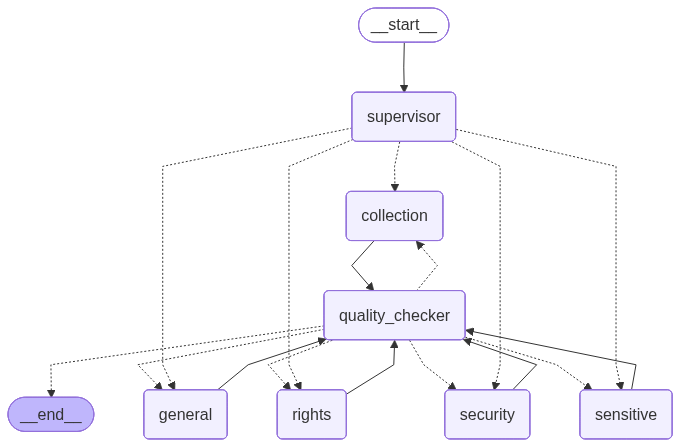

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## Step 8. 테스트

각 테스트에서 supervisor가 어떤 에이전트를 선택하는지 확인합니다.

In [10]:
# 테스트 1 → collection 에이전트 예상
query = '고객 정보를 마케팅 회사에 제공하려면 어떤 동의를 받아야 하나요?'
print(f'질문: {query}\n')

result = graph.invoke({'query': query, 'retry_count': 0})
print(f'\n선택된 에이전트: {result["selected_agent"]}')
print(f'\n=== 최종 답변 ===')
print(result['answer'])

질문: 고객 정보를 마케팅 회사에 제공하려면 어떤 동의를 받아야 하나요?



c:\workspace\langgraph_work\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteDecision(agent='coll...가 필요합니다.'), input_type=RouteDecision])
  return self.__pydantic_serializer__.to_python(


[supervisor] → collection | 이유: 고객 정보를 제3자에게 제공하기 위해서는 개인정보 수집 및 이용에 대한 동의가 필요합니다.
[collection_agent] 검색 중...
[collection_agent] 답변 생성 완료
[quality_checker] not hallucinated (retry: 0/2)

선택된 에이전트: collection

=== 최종 답변 ===
고객 정보를 마케팅 회사에 제공하려면 다음과 같은 동의를 받아야 합니다:

1. **정보주체의 동의**: 고객의 개인정보를 제3자에게 제공하기 위해서는 정보주체의 동의를 받아야 합니다(제17조 제1항 제1호).

2. **동의 시 안내 사항**: 동의를 받을 때에는 다음 각 호의 사항을 정보주체에게 알려야 합니다(제17조 제2항):
   - 개인정보를 제공받는 자
   - 개인정보를 제공받는 자의 개인정보 이용 목적
   - 제공하는 개인정보의 항목
   - 개인정보를 제공받는 자의 개인정보 보유 및 이용 기간
   - 동의를 거부할 권리가 있다는 사실 및 동의 거부에 따른 불이익이 있는 경우 그 불이익의 내용

이와 같은 절차를 통해 고객의 개인정보를 마케팅 회사에 제공할 수 있습니다.


In [11]:
# 테스트 2 → sensitive 에이전트 예상
query = '직원 채용 과정에서 건강검진 결과를 수집해도 되나요?'
print(f'질문: {query}\n')

result = graph.invoke({'query': query, 'retry_count': 0})
print(f'\n선택된 에이전트: {result["selected_agent"]}')
print(f'\n=== 최종 답변 ===')
print(result['answer'])

질문: 직원 채용 과정에서 건강검진 결과를 수집해도 되나요?



c:\workspace\langgraph_work\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteDecision(agent='sens...토해야 합니다.'), input_type=RouteDecision])
  return self.__pydantic_serializer__.to_python(


[supervisor] → sensitive | 이유: 직원 채용 과정에서 건강검진 결과는 민감정보에 해당하므로, 관련 법규에 따라 수집이 가능 여부를 검토해야 합니다.
[sensitive_agent] 검색 중...
[sensitive_agent] 답변 생성 완료
[quality_checker] not hallucinated (retry: 0/2)

선택된 에이전트: sensitive

=== 최종 답변 ===
직원 채용 과정에서 건강검진 결과는 민감정보에 해당하므로, 개인정보처리자는 원칙적으로 이를 처리할 수 없습니다. 그러나 다음의 경우에는 예외적으로 건강검진 결과를 수집할 수 있습니다:

1. 정보주체에게 제15조제2항 각 호 또는 제17조제2항 각 호의 사항을 알리고, 다른 개인정보의 처리에 대한 동의와 별도로 동의를 받은 경우.
2. 법령에서 민감정보의 처리를 요구하거나 허용하는 경우.

따라서, 건강검진 결과를 수집하기 위해서는 위의 조건을 충족해야 합니다.


In [12]:
# 테스트 3 → security 에이전트 예상
query = '개인정보 유출이 발생했을 때 몇 시간 안에 신고해야 하나요?'
print(f'질문: {query}\n')

result = graph.invoke({'query': query, 'retry_count': 0})
print(f'\n선택된 에이전트: {result["selected_agent"]}')
print(f'\n=== 최종 답변 ===')
print(result['answer'])

질문: 개인정보 유출이 발생했을 때 몇 시간 안에 신고해야 하나요?



c:\workspace\langgraph_work\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteDecision(agent='secu...가 적합합니다.'), input_type=RouteDecision])
  return self.__pydantic_serializer__.to_python(


[supervisor] → security | 이유: 개인정보 유출 신고 의무에 대한 질문이므로 안전조치 관련 에이전트가 적합합니다.
[security_agent] 검색 중...
[security_agent] 답변 생성 완료
[quality_checker] hallucinated (retry: 0/2)
[security_agent] 검색 중...
[security_agent] 답변 생성 완료
[quality_checker] hallucinated (retry: 1/2)
[security_agent] 검색 중...
[security_agent] 답변 생성 완료
[quality_checker] hallucinated (retry: 2/2)
[quality_checker] 최대 재시도 초과 → END

선택된 에이전트: security

=== 최종 답변 ===
법령에서 확인되지 않는 내용입니다.


In [13]:
# 테스트 4 → rights 에이전트 예상
query = '앱을 탈퇴했는데 회사가 내 개인정보를 계속 보관하고 있어요. 어떤 권리를 행사할 수 있나요?'
print(f'질문: {query}\n')

result = graph.invoke({'query': query, 'retry_count': 0})
print(f'\n선택된 에이전트: {result["selected_agent"]}')
print(f'\n=== 최종 답변 ===')
print(result['answer'])

질문: 앱을 탈퇴했는데 회사가 내 개인정보를 계속 보관하고 있어요. 어떤 권리를 행사할 수 있나요?



c:\workspace\langgraph_work\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteDecision(agent='righ...할 수 있습니다.'), input_type=RouteDecision])
  return self.__pydantic_serializer__.to_python(


[supervisor] → rights | 이유: 사용자는 개인정보의 열람, 정정, 삭제 및 처리정지 등의 권리를 행사할 수 있습니다.
[rights_agent] 검색 중...
[rights_agent] 답변 생성 완료
[quality_checker] not hallucinated (retry: 0/2)

선택된 에이전트: rights

=== 최종 답변 ===
앱을 탈퇴한 후에도 회사가 귀하의 개인정보를 계속 보관하고 있다면, 귀하는 다음과 같은 권리를 행사할 수 있습니다:

1. **개인정보의 열람 요구**: 귀하는 자신의 개인정보에 대한 열람을 요구할 수 있습니다. 이를 통해 어떤 정보가 보관되고 있는지 확인할 수 있습니다(제35조).

2. **정정 또는 삭제 요구**: 귀하는 개인정보처리자에게 귀하의 개인정보의 정정 또는 삭제를 요구할 수 있습니다. 다만, 다른 법령에서 그 개인정보가 수집 대상으로 명시되어 있는 경우에는 삭제를 요구할 수 없습니다(제36조).

3. **처리 정지 요구**: 귀하는 개인정보처리자에게 자신의 개인정보 처리의 정지를 요구할 수 있습니다(제37조). 이 경우, 개인정보처리자는 귀하의 요구에 따라 개인정보 처리의 전부 또는 일부를 정지해야 합니다.

이러한 권리를 행사하기 위해서는 개인정보처리자에게 요청을 하여야 하며, 요청에 대한 결과를 지체 없이 통보받을 수 있습니다.


In [14]:
# 테스트 5 → general 에이전트 예상
query = '개인정보보호법에서 개인정보처리자란 무엇인가요?'
print(f'질문: {query}\n')

result = graph.invoke({'query': query, 'retry_count': 0})
print(f'\n선택된 에이전트: {result["selected_agent"]}')
print(f'\n=== 최종 답변 ===')
print(result['answer'])

질문: 개인정보보호법에서 개인정보처리자란 무엇인가요?



c:\workspace\langgraph_work\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouteDecision(agent='gene...가 적합합니다.'), input_type=RouteDecision])
  return self.__pydantic_serializer__.to_python(


[supervisor] → general | 이유: 법의 목적, 정의, 원칙에 대한 질문이므로 일반 에이전트가 적합합니다.
[general_agent] 검색 중...
[general_agent] 답변 생성 완료
[quality_checker] not hallucinated (retry: 0/2)

선택된 에이전트: general

=== 최종 답변 ===
개인정보처리자란 업무를 목적으로 개인정보파일을 운용하기 위하여 스스로 또는 다른 사람을 통하여 개인정보를 처리하는 공공기관, 법인, 단체 및 개인 등을 말합니다.


## 확장 아이디어

현재 아키텍처에서 추가로 발전시킬 수 있는 방향:

### 1. 병렬 멀티 에이전트 (복합 질문 처리)
```python
# 여러 에이전트를 동시에 실행하고 결과를 합치는 synthesizer 추가
supervisor → [collection_agent, rights_agent]  # 병렬 실행
          → synthesizer (답변 통합)
          → quality_checker
          → END
```

### 2. 메모리 추가 (대화 히스토리)
```python
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)
# 이전 대화 맥락을 유지하며 후속 질문 처리
```

### 3. Human-in-the-Loop
```python
# 민감한 판단(손해배상 금액 등)에서 사람 검토 단계 추가
builder.add_node('human_review', interrupt_before=['rights_agent'])
```

### 4. 에이전트 간 협업 (Agent Handoff)
```python
# collection_agent가 민감정보 관련 내용 발견 시 sensitive_agent에게 위임
# → supervisor 없이 에이전트끼리 직접 라우팅
```